# Stacked Bar Charts

C:\Users\Hojat\AppData\Local\Temp\ipykernel_22252\1736303821.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
C:\Users\Hojat\AppData\Local\Temp\ipykernel_22252\1736303821.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


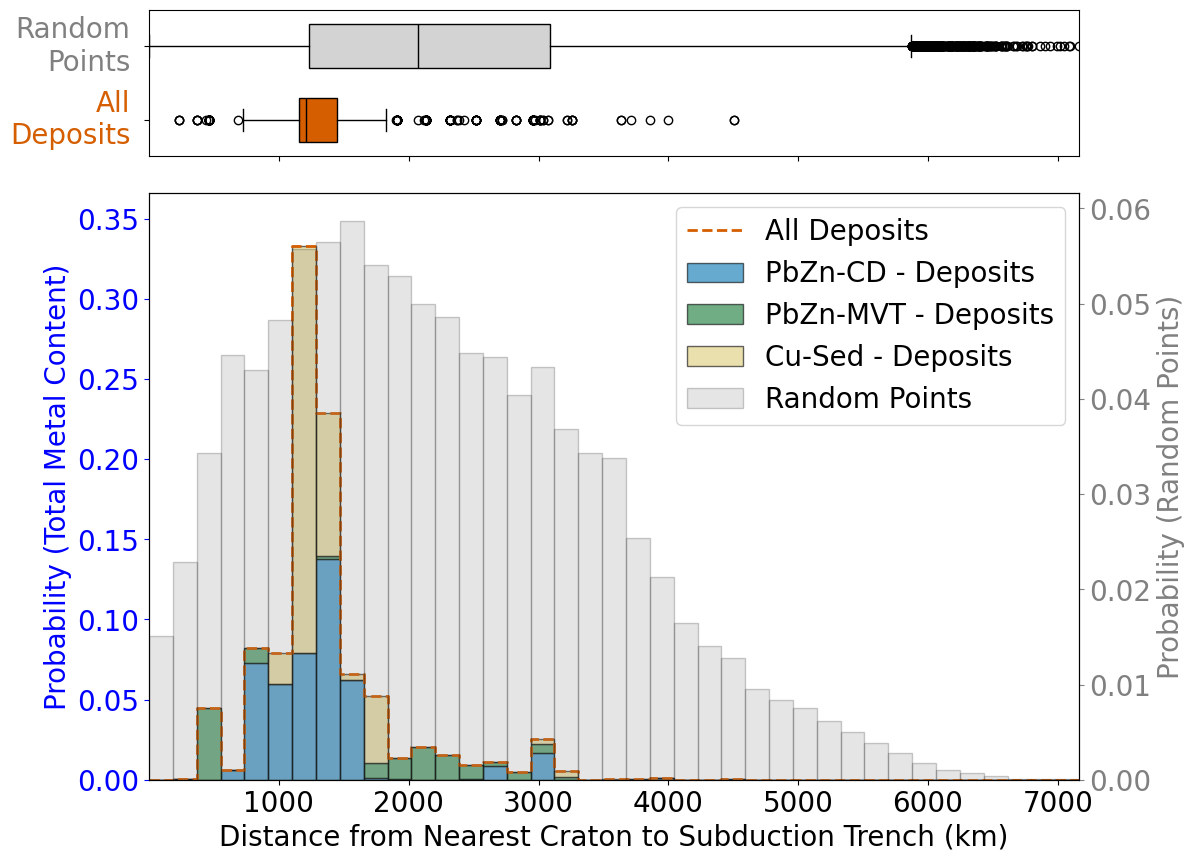

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load data
file_path = 'deposits_VS_random.csv'
df = pd.read_csv(file_path, low_memory=False)
df = df[df['Type'] != 'IOCG']
df['Type'] = df['Type'].fillna('Unknown')

# Colors
type_colors = {
    'PbZn-CD': '#0072B2',
    'PbZn-MVT': '#117733',
    'Cu-Sed': '#DDCC77',
    'IOCG': '#CC6677'
}

def plot_with_centered_boxplot_labels(df, deposit_column, random_column, weights_column, type_colors):
    unique_types = df['Type'].unique()

    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.1)

    ax_box = plt.subplot(gs[0])
    ax_box.tick_params(axis='x', labelbottom=False)
    ax_box.set_xlim(df[[deposit_column, random_column]].min().min(), df[[deposit_column, random_column]].max().max())

    weighted_deposits = df[[deposit_column, weights_column]].dropna()
    repeated_deposits = np.repeat(
        weighted_deposits[deposit_column].values,
        weighted_deposits[weights_column].round().astype(int).clip(1, 100)
    )
    random_data = df[random_column].dropna().values

    box_colors = ['#D55E00', 'lightgray']
    bp = ax_box.boxplot(
        [repeated_deposits, random_data],
        vert=False,
        patch_artist=True,
        widths=0.6,
        labels=['', '']
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
    for median in bp['medians']:
        median.set_color('black')

    # Better vertical centering for labels
    min_val = df[[deposit_column, random_column]].min().min()
    label_x = min_val - (df[[deposit_column, random_column]].max().max() - min_val) * 0.02

    ax_box.set_yticks([1, 2])
    ax_box.set_yticklabels(['', ''])
    ax_box.text(label_x, 1, 'All\nDeposits', fontsize=20, ha='right', va='center', color='#D55E00')
    ax_box.text(label_x, 2, 'Random\nPoints', fontsize=20, ha='right', va='center', color='gray')

    ax1 = plt.subplot(gs[1])
    ax2 = ax1.twinx()

    bin_edges = np.linspace(min_val, df[[deposit_column, random_column]].max().max(), 40)
    bin_centers = bin_edges[:-1] + (bin_edges[1] - bin_edges[0]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    bottom = np.zeros(len(bin_edges) - 1)
    total_metal = df[weights_column].sum()

    for deposit_type in unique_types:
        if deposit_type == 'Unknown':
            continue
        type_data = df[df['Type'] == deposit_type]
        deposit_data = type_data[deposit_column].dropna()
        deposit_weights = type_data.loc[deposit_data.index, weights_column]
        if len(deposit_data) > 0:
            counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights)
            if total_metal > 0:
                counts = counts / total_metal
            ax1.bar(
                bin_centers,
                counts,
                width=bin_width,
                color=type_colors.get(deposit_type, 'gray'),
                alpha=0.6,
                edgecolor='black',
                bottom=bottom,
                label=f'{deposit_type} - Deposits'
            )
            bottom += counts

    # Dashed line over the top of the stacked deposit bars
    ax1.step(
        bin_edges,
        np.append(bottom, bottom[-1]),  # extend last height
        where='post',
        linestyle='--',
        linewidth=2,
        color='#D55E00',
        label='All Deposits'
    )

    if len(random_data) > 0:
        rcounts, _ = np.histogram(random_data, bins=bin_edges)
        rprob = rcounts / rcounts.sum()
        ax2.bar(
            bin_centers,
            rprob,
            width=bin_width,
            color='gray',
            alpha=0.2,
            edgecolor='black',
            label='Random Points'
        )

    font_size = 20
    ax1.set_xlabel('Distance from Nearest Craton to Subduction Trench (km)', fontsize=font_size)
    ax1.set_ylabel('Probability (Total Metal Content)', fontsize=font_size, color='blue')
    ax2.set_ylabel('Probability (Random Points)', fontsize=font_size, color='gray')
    ax1.tick_params(axis='x', labelsize=font_size)
    ax1.tick_params(axis='y', labelsize=font_size, colors='blue')
    ax2.tick_params(axis='y', labelsize=font_size, colors='gray')
    ax1.set_xlim([min_val, df[[deposit_column, random_column]].max().max()])
    ax1.set_ylim(0, max(bottom.max(), rprob.max() if len(random_data) > 0 else 0) * 1.1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    filtered_legend = [(l, lab) for l, lab in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in lab]
    if filtered_legend:
        handles, labels = zip(*filtered_legend)
        ax1.legend(handles, labels, loc='upper right', fontsize=font_size)

    plt.tight_layout()
    plt.show()

# Run it
plot_with_centered_boxplot_labels(
    df,
    deposit_column='D_ds_cr_tr',
    random_column='R_ds_cr_tr',
    weights_column='TM2',
    type_colors=type_colors
)


In [4]:
pip install statsmodels

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 74.8 MB/s eta 0:00:00
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmo

In [5]:
from statsmodels.stats.weightstats import DescrStatsW

# Weighted median for deposits
weighted_deposit_data = df[['D_ds_cr_tr', 'TM2']].dropna()
weighted_stats = DescrStatsW(weighted_deposit_data['D_ds_cr_tr'], weights=weighted_deposit_data['TM2'])
weighted_median_deposit = weighted_stats.quantile(0.5)

# Median for random points
random_data = df['R_ds_cr_tr'].dropna()
median_random = np.median(random_data)

# Print results
print(f"Weighted median of deposits: {weighted_median_deposit}")
print(f"Median of random points: {median_random}")


Weighted median of deposits: p
0.5    1208.760196
dtype: float64
Median of random points: 2070.139268


In [32]:
# Drop rows with NaN in 'D_ds_cr_tr' or 'TM2' before calculating the weighted average
df_cleaned = df.dropna(subset=['D_ds_cr_tr', 'TM2'])

# Calculate the weighted average of 'D_ds_cr_tr' using 'TM2' as weights
weighted_avg_D_ds_cr_tr = np.average(df_cleaned['D_ds_cr_tr'], weights=df_cleaned['TM2'])

# Calculate the unweighted average of 'R_ds_cr_tr'
avg_R_ds_cr_tr = df['R_ds_cr_tr'].mean()

# Calculate the unweighted average of 'R_ds_tr'
avg_R_ds_tr = df['R_ds_tr'].mean()

# Print the results
print("Weighted average of D_ds_cr_tr (weighted with TM2):", weighted_avg_D_ds_cr_tr)
print("Average of R_ds_cr_tr:", avg_R_ds_cr_tr)
print("Average of R_ds_tr:", avg_R_ds_tr)


Weighted average of D_ds_cr_tr (weighted with TM2): 1392.4988210720983
Average of R_ds_cr_tr: 2229.4360347414863
Average of R_ds_tr: 2118.8574267192557


In [34]:
import pandas as pd
import numpy as np

# Assuming df is the DataFrame containing your data
# Drop rows with NaN in 'D_ds_cr_tr' or 'TM2' before calculating the mode
df_cleaned = df.dropna(subset=['D_ds_cr_tr', 'TM2'])

# Calculate the mode of 'D_ds_cr_tr' (no weights used for mode calculation)
mode_D_ds_cr_tr = df_cleaned['D_ds_cr_tr'].mode()[0]

# Calculate the unweighted mode of 'R_ds_cr_tr'
mode_R_ds_cr_tr = df['R_ds_cr_tr'].mode()[0]

# Calculate the unweighted mode of 'R_ds_tr'
mode_R_ds_tr = df['R_ds_tr'].mode()[0]

# Print the results
print("Mode of D_ds_cr_tr (after cleaning):", mode_D_ds_cr_tr)
print("Mode of R_ds_cr_tr:", mode_R_ds_cr_tr)
print("Mode of R_ds_tr:", mode_R_ds_tr)


Mode of D_ds_cr_tr (after cleaning): 1312.192496
Mode of R_ds_cr_tr: 926.5401301
Mode of R_ds_tr: 2404.6028


In [2]:
import pandas as pd
import numpy as np

# Assuming df is the DataFrame containing your data
# Drop rows with NaN in 'D_ds_cr_tr' or 'TM2' before calculating MAD
df_cleaned = df.dropna(subset=['D_ds_cr_tr', 'TM2'])

# Calculate the MAD for 'D_ds_cr_tr' (after cleaning)
mad_D_ds_cr_tr = np.median(np.abs(df_cleaned['D_ds_cr_tr'] - np.median(df_cleaned['D_ds_cr_tr'])))

# Calculate the MAD for 'R_ds_cr_tr'
mad_R_ds_cr_tr = np.median(np.abs(df['R_ds_cr_tr'] - np.median(df['R_ds_cr_tr'])))

# Calculate the MAD for 'R_ds_tr'
mad_R_ds_tr = np.median(np.abs(df['R_ds_tr'] - np.median(df['R_ds_tr'])))

# Print the results
print("MAD of D_ds_cr_tr (after cleaning):", mad_D_ds_cr_tr)
print("MAD of R_ds_cr_tr:", mad_R_ds_cr_tr)
print("MAD of R_ds_tr:", mad_R_ds_tr)


MAD of D_ds_cr_tr (after cleaning): 267.027206
MAD of R_ds_cr_tr: 913.3028835
MAD of R_ds_tr: 1039.92260355


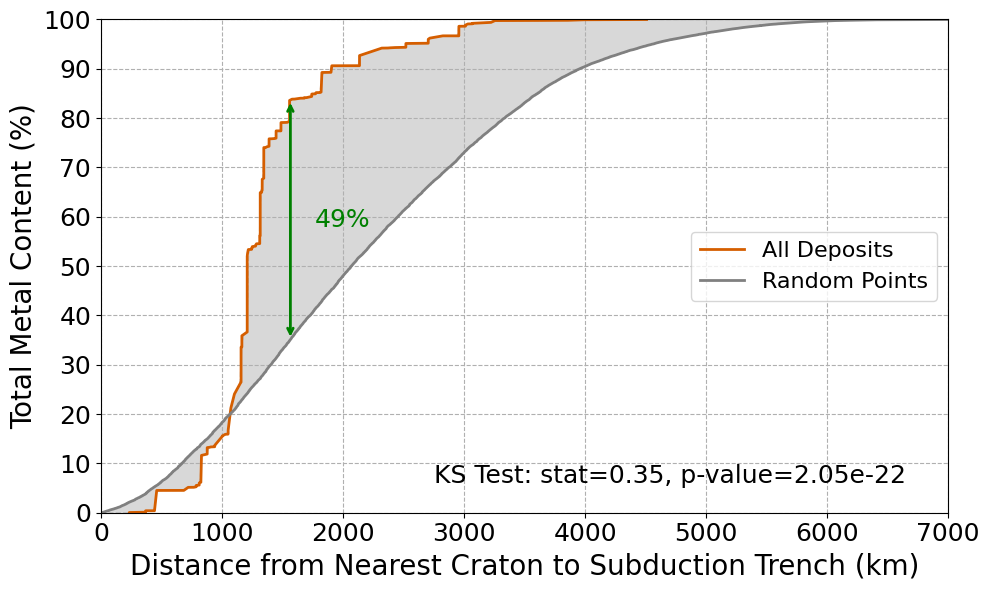

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Load data
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)

# Filter data
df = df[(df['R_ds_cr_tr'] >= 0) & (df['R_ds_cr_tr'] <= 8500)]
df = df[df['Type'] != 'IOCG']

# Prepare data
deposit_data = df['D_ds_cr_tr'].dropna()
deposit_weights = df['TM2'].dropna()
random_data = df['R_ds_cr_tr'].dropna()

# ECDF for weighted data
def weighted_ecdf(data, weights):
    sorted_data, sorted_weights = zip(*sorted(zip(data, weights)))
    sorted_data = np.array(sorted_data)
    sorted_weights = np.array(sorted_weights)
    cumsum_weights = np.cumsum(sorted_weights)
    cdf = cumsum_weights / cumsum_weights[-1]  # Normalize to get ECDF
    return sorted_data, cdf

# ECDF for unweighted data
def ecdf(data):
    sorted_data = np.sort(data)
    yvals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, yvals

# Get ECDFs
x_deposit, y_deposit = weighted_ecdf(deposit_data, deposit_weights)
x_random, y_random = ecdf(random_data)

# Kolmogorov–Smirnov test
ks_stat, ks_p_value = ks_2samp(deposit_data, random_data)

# Interpolate ECDFs for comparison
common_x = np.linspace(min(min(x_deposit), min(x_random)), max(max(x_deposit), max(x_random)), 500)
y_deposit_interpolated = np.interp(common_x, x_deposit, y_deposit)
y_random_interpolated = np.interp(common_x, x_random, y_random)
abs_distance = np.abs(y_deposit_interpolated - y_random_interpolated)

# Get max distance between ECDFs
max_distance_index = np.argmax(abs_distance)
max_distance_value = abs_distance[max_distance_index]
max_x_value = common_x[max_distance_index]
max_y_deposit = y_deposit_interpolated[max_distance_index]
max_y_random = y_random_interpolated[max_distance_index]

# Convert ECDFs to percent
y_deposit *= 100
y_random *= 100
y_deposit_interpolated *= 100
y_random_interpolated *= 100
max_y_deposit *= 100
max_y_random *= 100
max_distance_value *= 100

# Plotting
plt.figure(figsize=(10, 6))

# Plot ECDFs
plt.plot(x_deposit, y_deposit, linestyle='-', color='#D55E00', label='All Deposits', linewidth=2)
plt.plot(x_random, y_random, linestyle='-', color='gray', label='Random Points', linewidth=2)

# Fill between ECDFs
plt.fill_between(common_x, y_deposit_interpolated, y_random_interpolated, color='gray', alpha=0.3, linestyle='--')

# Axis limits and ticks
plt.xlim(0, 7000)
plt.ylim(0, 100)
plt.xticks(np.arange(0, 7001, 1000), fontsize=18)
plt.yticks(np.arange(0, 101, 10), fontsize=18)

# Labels and title
plt.xlabel('Distance from Nearest Craton to Subduction Trench (km)', fontsize=20)
plt.ylabel('Total Metal Content (%)', fontsize=20)
#plt.title('ECDFs Comparison', fontsize=18)
plt.legend(fontsize=16)

# Annotate maximum distance
plt.annotate('', xy=(max_x_value, max_y_deposit), xytext=(max_x_value, max_y_random),
             arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='<->', lw=2))

plt.text(max_x_value + 200, (max_y_deposit + max_y_random) / 2, f'{max_distance_value:.0f}%', 
         horizontalalignment='left', verticalalignment='center', fontsize=18, color='green')

# KS Test result
plt.text(0.95, 0.05, f'KS Test: stat={ks_stat:.2f}, p-value={ks_p_value:.2e}', ha='right', va='bottom', 
         transform=plt.gca().transAxes, fontsize=18)

plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


In [9]:
!pip install seaborn

# Scatterplots

# 3-axis stacked bar chart

# swap axes

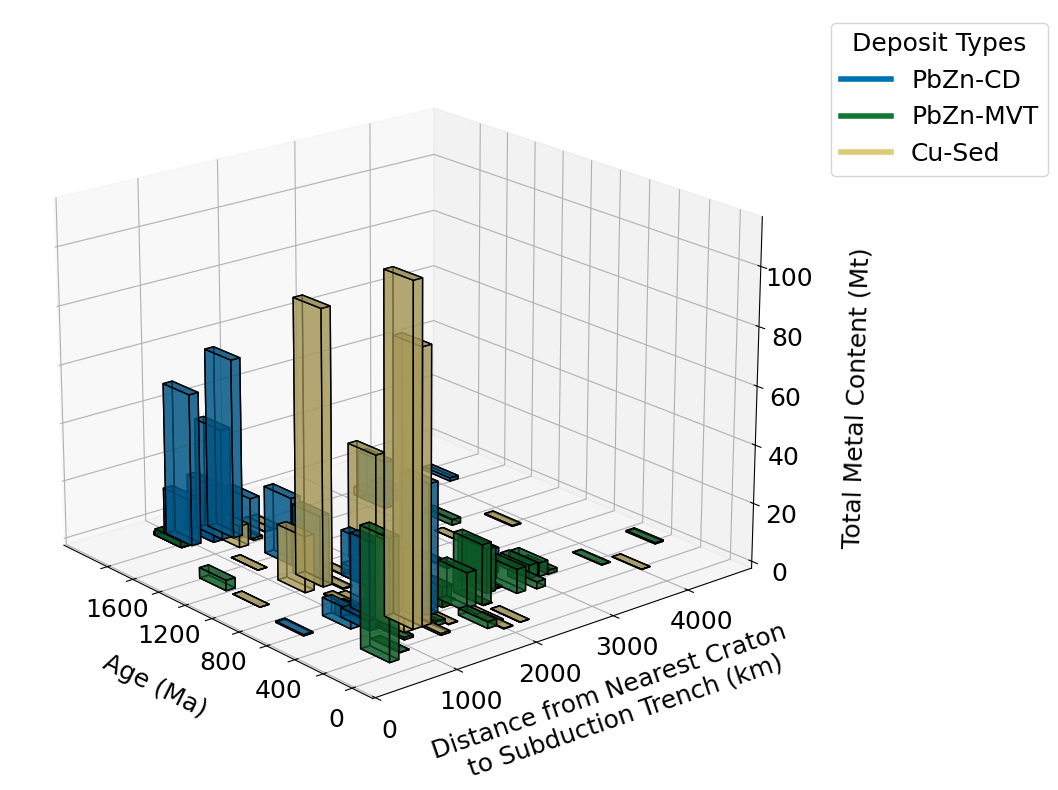

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = './deposits_VS_random.csv'  # Replace with your file path
data = pd.read_csv(file_path, low_memory=False)
data = data[data['Type'] != 'IOCG']

# Remove rows with NaN values in relevant columns
filtered_data = data.dropna(subset=['D_ds_cr_tr', 'Age', 'TM2', 'Type'])

# Define custom colors
custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# Set bin size exactly as provided
previous_min_val = 0  # Start from 0
previous_max_val = filtered_data['D_ds_cr_tr'].max()
num_bins = 40  # Same number of bins as in previous charts
bin_edges = np.linspace(previous_min_val, previous_max_val, num_bins + 1)  # Ensure 40 bins
bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# Prepare X-axis intervals with steps of 200 for Age
x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# Remove every other label from Age axis (X-axis)
x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# Create the 3D bar chart
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Adjust the view angle
ax.view_init(elev=20, azim=-40)

# Map deposit types to custom colors
deposit_types = filtered_data['Type'].unique()
type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# Iterate through ages (X-axis now) and distances (Y-axis) to plot bars
for j, age in enumerate(filtered_data['Age'].unique()):
    for i in range(len(bin_edges) - 1):
        subset = filtered_data[(filtered_data['D_ds_cr_tr'] >= bin_edges[i]) &
                               (filtered_data['D_ds_cr_tr'] < bin_edges[i + 1]) &
                               (filtered_data['Age'] == age)]
        if not subset.empty:
            weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
            deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
            ax.bar3d(
                age, y_positions[i], 0,  # Swapped X (Age) and Y (Distance)
                200, bin_widths[i], weighted_count,  # Width (Age), Depth (Distance), Height
                color=type_color_mapping[deposit_type],  # Mapped color
                edgecolor='k',  # Add black edges to bars
                alpha=0.6,  # Transparency
                shade=True
            )

# Add legend with doubled font sizes
legend_handles = [
    plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
    for deposit_type in deposit_types
]
legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
                    bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# Customize the chart with swapped axes
ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
ax.set_ylabel('Distance from Nearest Craton \n to Subduction Trench (km)', fontsize=18, labelpad=20)
ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=20)

# Update Age axis ticks and remove every other label
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=18)

ax.tick_params(axis='both', labelsize=18)

# Invert Age axis to start from the other side
ax.invert_xaxis()

# Title removed for a cleaner look
plt.show()


In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the dataset
# file_path = './deposits_VS_random.csv'  # Replace with your file path
# data = pd.read_csv(file_path, low_memory=False)
# data = data[data['Type'] != 'IOCG']

# # Remove rows with NaN values in relevant columns
# filtered_data = data.dropna(subset=['Age', 'TM2', 'Type'])

# # Define custom colors
# custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# # Prepare the plot
# fig = plt.figure(figsize=(14, 10))
# ax = fig.add_subplot(111)

# # Map deposit types to custom colors
# deposit_types = filtered_data['Type'].unique()
# type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# # Plot bubbles (scatter plot)
# for deposit_type in deposit_types:
#     subset = filtered_data[filtered_data['Type'] == deposit_type]
    
#     # Bubble sizes are proportional to the total metal content (TM2)
#     bubble_sizes = subset['TM2'] * 10  # Scale up for better visibility, adjust the factor if needed
    
#     ax.scatter(
#         subset['Age'],  # X-axis: Age
#         np.zeros(len(subset)),  # Y-axis: Set to zero to plot along a single horizontal line
#         s=bubble_sizes,  # Size of the bubble: Total metal content (TM2)
#         color=type_color_mapping[deposit_type],  # Color mapped to deposit type
#         alpha=0.6,  # Transparency of bubbles
#         edgecolor='black',  # Black border around the bubbles
#         linewidth=1,  # Line width of the border
#         label=deposit_type
#     )

# # Customize the chart
# ax.set_xlabel('Age (Ma)', fontsize=18)
# ax.set_ylabel('Metal Content (TM2)', fontsize=18)
# ax.set_title('Age vs Metal Content with Deposit Types', fontsize=20)

# # Add a legend
# legend = ax.legend(title="Deposit Types", loc="upper left", fontsize=18, title_fontsize=18)

# # Show the plot
# plt.xticks(fontsize=16)
# plt.yticks([])  # Remove the y-ticks since we're not using the y-axis
# plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_3188\378356716.py:9: DtypeWarning: Columns (2,3,4,5,6,7,12,22,26,27,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


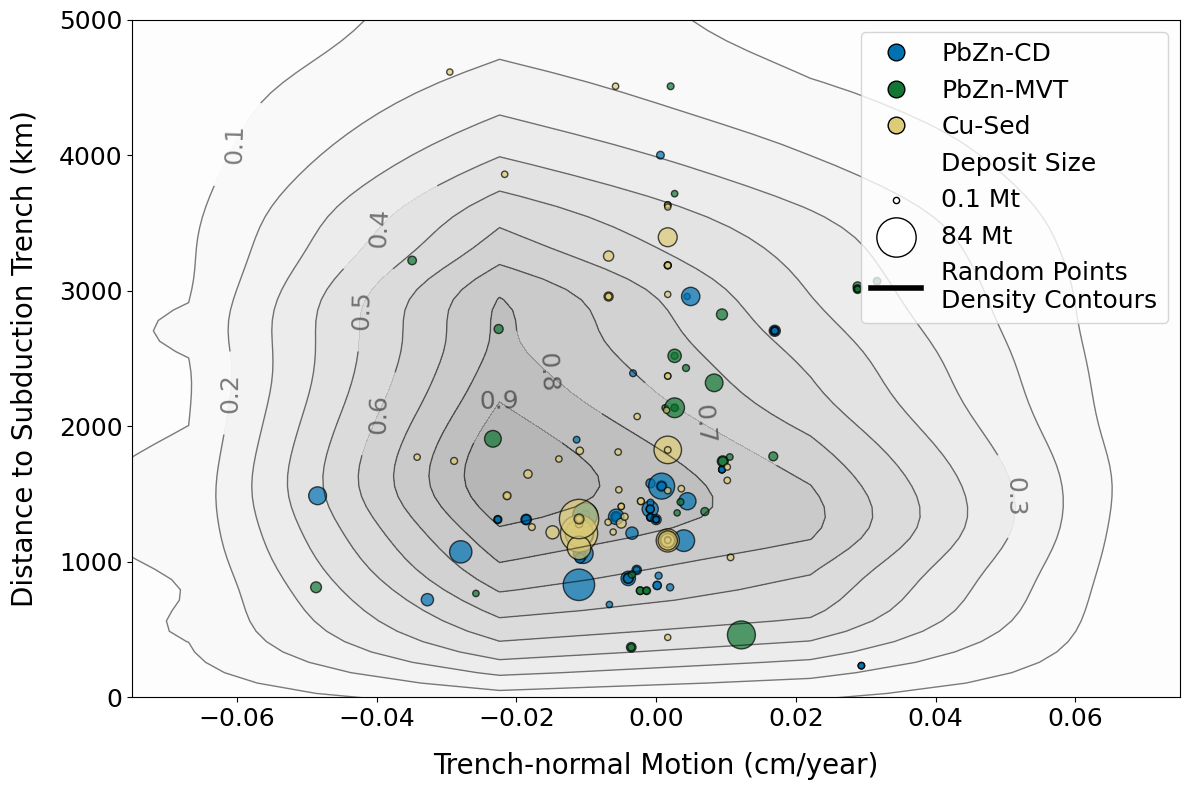

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'
df = pd.read_csv(file_path)
df = df[df['Type'] != 'IOCG']

# Define columns
x_deposit = 'D_tr_adv_m'
y_deposit = 'D_ds_cr_tr'
x_random = 'R_tr_adv_m'
y_random = 'R_ds_cr_tr'
weights_column = 'TM2'

# Keep all values, including negatives
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']].dropna()
random_data = df[[x_random, y_random]].dropna()

# Extract values
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors
type_colors = {
    'PbZn-CD': '#0072B2',
    'PbZn-MVT': '#117733',
    'Cu-Sed': '#DDCC77',
    #'IOCG': '#CC6677',
    'Unknown': 'gray'
}

# Scale sizes based on TM2
min_size, max_size = 20, 800
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
xx, yy = np.meshgrid(
    np.linspace(x_random_values.min() - 2, x_random_values.max() + 2, 100),
    np.linspace(y_random_values.min() - 200, y_random_values.max() + 200, 100)
)

values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")

# Scatter deposits by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=deposit_type)

# Legend elements
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color=color, label=deposit_type,
                       markersize=12, markeredgecolor='black', linestyle='None')
        )

# Deposit size legend
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', edgecolor='black', label='0.1 Mt'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', edgecolor='black', label='84 Mt'))

# Random point contour legend
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4,
                                  label='Random Points\nDensity Contours'))

# Labels and formatting
plt.xlabel('Trench-normal Motion (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Distance to Subduction Trench (km)', fontsize=20, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Axis limits: x from deposits, y from random
#plt.xlim(x_deposit_values.min() - 2, x_deposit_values.max() + 2)
plt.xlim(-0.075, 0.075)
#plt.ylim(y_random_values.min() - 200, y_random_values.max() + 200)
plt.ylim(0, 5000)

# Legend
plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,
           fontsize=18, title_fontsize=20)

# Final layout
plt.tight_layout()
plt.show()


# Distance

In [57]:
# 1. Percentage of deposits (weighted by TM2) between 700 and 2200
df = df[df['Type'] != 'IOCG']

deposit_data_all = df[~df['D_ds_cr_tr'].isna()]
deposits_in_range = deposit_data_all[(deposit_data_all['D_ds_cr_tr'] >= 460) & (deposit_data_all['D_ds_cr_tr'] <= 2000)]
weighted_total_deposits = deposit_data_all['TM2'].sum()
weighted_in_range = deposits_in_range['TM2'].sum()
percentage_deposits_in_range = 100 * weighted_in_range / weighted_total_deposits

# 2. Percentage of random points between 700 and 2200 (unweighted count)
random_data_all = df[~df['R_ds_cr_tr'].isna()]
randoms_in_range = random_data_all[(random_data_all['R_ds_cr_tr'] >= 460) & (random_data_all['R_ds_cr_tr'] <= 2000)]
percentage_randoms_in_range = 100 * len(randoms_in_range) / len(random_data_all)

# Print results
print(f"Percentage of deposit metal content between ... and ...: {percentage_deposits_in_range:.2f}%")
print(f"Percentage of random points between ... and ...: {percentage_randoms_in_range:.2f}%")


Percentage of deposit metal content between ... and ...: 88.33%
Percentage of random points between ... and ...: 41.13%


In [30]:
# 1. Percentage of deposits (weighted by TM2) between 700 and 2200
df = df[df['Type'] != 'IOCG']

deposit_data_all = df[~df['D_ds_cr_tr'].isna()]
deposits_in_range = deposit_data_all[(deposit_data_all['D_ds_cr_tr'] >= 460) & (deposit_data_all['D_ds_cr_tr'] <= 1560)]
weighted_total_deposits = deposit_data_all['TM2'].sum()
weighted_in_range = deposits_in_range['TM2'].sum()
percentage_deposits_in_range = 100 * weighted_in_range / weighted_total_deposits

# 2. Percentage of random points between 700 and 2200 (unweighted count)
random_data_all = df[~df['R_ds_cr_tr'].isna()]
randoms_in_range = random_data_all[(random_data_all['R_ds_cr_tr'] >= 460) & (random_data_all['R_ds_cr_tr'] <= 1560)]
percentage_randoms_in_range = 100 * len(randoms_in_range) / len(random_data_all)

# Print results
print(f"Percentage of deposit metal content between ... and ...: {percentage_deposits_in_range:.2f}%")
print(f"Percentage of random points between ... and ...: {percentage_randoms_in_range:.2f}%")


Percentage of deposit metal content between ... and ...: 81.27%
Percentage of random points between ... and ...: 29.41%


In [2]:
# 1. Percentage of deposits (weighted by TM2) between 700 and 2200
df = df[df['Type'] != 'IOCG']

deposit_data_all = df[~df['D_ds_cr_tr'].isna()]
deposits_in_range = deposit_data_all[(deposit_data_all['D_ds_cr_tr'] >= 1020) & (deposit_data_all['D_ds_cr_tr'] <= 1560)]
weighted_total_deposits = deposit_data_all['TM2'].sum()
weighted_in_range = deposits_in_range['TM2'].sum()
percentage_deposits_in_range = 100 * weighted_in_range / weighted_total_deposits

# 2. Percentage of random points between 700 and 2200 (unweighted count)
random_data_all = df[~df['R_ds_tr'].isna()]
randoms_in_range = random_data_all[(random_data_all['R_ds_tr'] >= 1020) & (random_data_all['R_ds_tr'] <= 1560)]
percentage_randoms_in_range = 100 * len(randoms_in_range) / len(random_data_all)

# Print results
print(f"Percentage of deposit metal content between ... and ...: {percentage_deposits_in_range:.2f}%")
print(f"Percentage of random points between ... and ...: {percentage_randoms_in_range:.2f}%")


Percentage of deposit metal content between ... and ...: 68.02%
Percentage of random points between ... and ...: 14.49%


# Distance 2

In [3]:
# 1. Percentage of deposits (weighted by TM2) between 700 and 2200
df = df[df['Type'] != 'IOCG']

deposit_data_all = df[~df['D_ds_cr_tr'].isna()]
deposits_in_range = deposit_data_all[(deposit_data_all['D_ds_cr_tr'] >= 1020) & (deposit_data_all['D_ds_cr_tr'] <= 1560)]
weighted_total_deposits = deposit_data_all['TM2'].sum()
weighted_in_range = deposits_in_range['TM2'].sum()
percentage_deposits_in_range = 100 * weighted_in_range / weighted_total_deposits

# 2. Percentage of random points between 700 and 2200 (unweighted count)
random_data_all = df[~df['R_ds_cr_tr'].isna()]
randoms_in_range = random_data_all[(random_data_all['R_ds_cr_tr'] >= 1020) & (random_data_all['R_ds_cr_tr'] <= 1560)]
percentage_randoms_in_range = 100 * len(randoms_in_range) / len(random_data_all)

# Print results
print(f"Percentage of deposit metal content between ... and ...: {percentage_deposits_in_range:.2f}%")
print(f"Percentage of random points between ... and ...: {percentage_randoms_in_range:.2f}%")


Percentage of deposit metal content between ... and ...: 68.02%
Percentage of random points between ... and ...: 16.14%


In [32]:
# 1. Percentage of deposits (weighted by TM2) between 700 and 2200
df = df[df['Type'] != 'IOCG']

deposit_data_all = df[~df['D_tr_adv_m'].isna()]
deposits_in_range = deposit_data_all[(deposit_data_all['D_tr_adv_m'] >= -0.012) & (deposit_data_all['D_tr_adv_m'] <= 0.013)]
weighted_total_deposits = deposit_data_all['TM2'].sum()
weighted_in_range = deposits_in_range['TM2'].sum()
percentage_deposits_in_range = 100 * weighted_in_range / weighted_total_deposits

# 2. Percentage of random points between 700 and 2200 (unweighted count)
random_data_all = df[~df['R_tr_adv_m'].isna()]
randoms_in_range = random_data_all[(random_data_all['R_tr_adv_m'] >= -0.012) & (random_data_all['R_tr_adv_m'] <= 0.013)]
percentage_randoms_in_range = 100 * len(randoms_in_range) / len(random_data_all)

# Print results
print(f"Percentage of deposit metal content between ... and ...: {percentage_deposits_in_range:.2f}%")
print(f"Percentage of random points between ... and ...: {percentage_randoms_in_range:.2f}%")


Percentage of deposit metal content between ... and ...: 89.07%
Percentage of random points between ... and ...: 50.52%


# determine 80% and 90%

In [33]:
# Filter valid deposit values
df = df[df['Type'] != 'IOCG']

deposit_data = df[~df['D_cr_ve'].isna()].copy()

# Sort by D_ds_tr to build cumulative distribution
deposit_data = deposit_data.sort_values(by='D_cr_ve')
deposit_data['cum_weight'] = deposit_data['TM2'].cumsum()
total_weight = deposit_data['TM2'].sum()
deposit_data['cum_percent'] = 100 * deposit_data['cum_weight'] / total_weight

# Find D_ds_tr thresholds for 80% and 90%
threshold_80 = deposit_data[deposit_data['cum_percent'] >= 80]['D_cr_ve'].iloc[0]
threshold_90 = deposit_data[deposit_data['cum_percent'] >= 90]['D_cr_ve'].iloc[0]

print(f"80% of total deposit metal content is within D_cr_ve ≤ {threshold_80:.1f} km")
print(f"90% of total deposit metal content is within D_cr_ve ≤ {threshold_90:.1f} km")


80% of total deposit metal content is within D_cr_ve ≤ 2.8 km
90% of total deposit metal content is within D_cr_ve ≤ 4.6 km


In [34]:
# Filter valid deposit values
df = df[df['Type'] != 'IOCG']

deposit_data = df[~df['D_sb_ve'].isna()].copy()

# Sort by D_ds_tr to build cumulative distribution
deposit_data = deposit_data.sort_values(by='D_sb_ve')
deposit_data['cum_weight'] = deposit_data['TM2'].cumsum()
total_weight = deposit_data['TM2'].sum()
deposit_data['cum_percent'] = 100 * deposit_data['cum_weight'] / total_weight

# Find D_ds_tr thresholds for 80% and 90%
threshold_80 = deposit_data[deposit_data['cum_percent'] >= 80]['D_sb_ve'].iloc[0]
threshold_90 = deposit_data[deposit_data['cum_percent'] >= 90]['D_sb_ve'].iloc[0]

print(f"80% of total deposit metal content is within D_sb_ve ≤ {threshold_80:.1f} km")
print(f"90% of total deposit metal content is within D_sb_ve ≤ {threshold_90:.1f} km")


80% of total deposit metal content is within D_sb_ve ≤ 3.5 km
90% of total deposit metal content is within D_sb_ve ≤ 6.2 km


In [37]:
# Filter valid deposit values
df = df[df['Type'] != 'IOCG']

deposit_data = df[~df['D_ds_cr_tr'].isna()].copy()

# Sort by D_ds_tr to build cumulative distribution
deposit_data = deposit_data.sort_values(by='D_ds_cr_tr')
deposit_data['cum_weight'] = deposit_data['TM2'].cumsum()
total_weight = deposit_data['TM2'].sum()
deposit_data['cum_percent'] = 100 * deposit_data['cum_weight'] / total_weight

# Find D_ds_tr thresholds for 80% and 90%
threshold_80 = deposit_data[deposit_data['cum_percent'] >= 80]['D_ds_cr_tr'].iloc[0]
threshold_90 = deposit_data[deposit_data['cum_percent'] >= 90]['D_ds_cr_tr'].iloc[0]

print(f"80% of total deposit metal content is within D_ds_tr ≤ {threshold_80:.1f} km")
print(f"90% of total deposit metal content is within D_ds_tr ≤ {threshold_90:.1f} km")


80% of total deposit metal content is within D_ds_tr ≤ 1558.6 km
90% of total deposit metal content is within D_ds_tr ≤ 2136.4 km


In [38]:
# Filter valid deposit values
df = df[df['Type'] != 'IOCG']

deposit_data = df[~df['D_tr_adv_m'].isna()].copy()

# Sort by D_ds_tr to build cumulative distribution
deposit_data = deposit_data.sort_values(by='D_tr_adv_m')
deposit_data['cum_weight'] = deposit_data['TM2'].cumsum()
total_weight = deposit_data['TM2'].sum()
deposit_data['cum_percent'] = 100 * deposit_data['cum_weight'] / total_weight

# Find D_ds_tr thresholds for 80% and 90%
threshold_80 = deposit_data[deposit_data['cum_percent'] >= 80]['D_tr_adv_m'].iloc[0]
threshold_90 = deposit_data[deposit_data['cum_percent'] >= 90]['D_tr_adv_m'].iloc[0]

print(f"80% of total deposit metal content is within D_ds_tr ≤ {threshold_80:.4f} km")
print(f"90% of total deposit metal content is within D_ds_tr ≤ {threshold_90:.4f} km")


80% of total deposit metal content is within D_ds_tr ≤ 0.0017 km
90% of total deposit metal content is within D_ds_tr ≤ 0.0050 km
